In [1]:
import h5py
# import jax
# jax.config.update("jax_enable_x64", True)
# from jax import numpy as jnp
# from jax import jit ,vmap
from scipy.interpolate import griddata
import matplotlib.pyplot as plt
# from scipy.signal import convolve2d, fftconvolve # check jax
# from jax.scipy.signal import fftconvolve
# from jax.scipy.interpolate import RegularGridInterpolator
# from jax.scipy.ndimage import map_coordinates
import time

import os
import numpy
import numpy as np

from numpy.random import randint
import sklearn as sk
from sklearn.mixture import GaussianMixture # jaxxx??? # Hyakkk
from sklearn.decomposition import SparsePCA
from scipy.io import loadmat
import matplotlib as mpl
from matplotlib.colors import ListedColormap
# Seaborn colormap
import seaborn as sns
sns_list = sns.color_palette('deep').as_hex()
sns_list.insert(0, '#ffffff')  # Insert white at zero position
sns_cmap = ListedColormap(sns_list)

cm = sns_cmap

mpl_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728',
            '#9467bd', '#8c564b', '#e377c2', '#7f7f7f',
            '#bcbd22', '#17becf']


In [2]:

labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$',
        r'$\nu \nabla \bar{\bf{u}}$', r'$\rho^{-1} \bar{p}_x$', 
        r'$\overline{({u^\prime} ^2)}_x$', r'$\overline{(u^\prime v^\prime)}_y$']
'''
Import Data
'''

referenceDNS = 'data/boxOutput500500.hdf5'
mean_file = 'data/Mean_1300000-1500000.hdf5'
with h5py.File(referenceDNS, "r") as file:
    list_keys = list(file.keys())[0]
    x = np.array(file[list_keys].get('x')).squeeze()
    y = np.array(file[list_keys].get('y')).squeeze()

with h5py.File(mean_file, "r") as file:
    list_keys = list(file.keys())[0]
    b = list(file[list_keys].keys()) 

    um = np.array(file[list_keys].get('um')[0,:,:]).squeeze()
    vm = np.array(file[list_keys].get('vm')[0,:,:]).squeeze()
    # wm = np.array(file[list_keys].get('wm')[0,:,:]).squeeze() # In theory, these should go to zero
    pm = np.array(file[list_keys].get('pm')[0,:,:]).squeeze()

    uu = np.array(file[list_keys].get('uu')[0,:,:]).squeeze()
    uv = np.array(file[list_keys].get('uv')[0,:,:]).squeeze()
    rhom = np.array(file[list_keys].get('rhom')[0,:,:]).squeeze()

# DNS params
ETA = 1.849e-5
RHO = 1.1839
u_tau_theory = 0.0629

'''
Import Data
'''

nu = ETA/RHO


In [3]:
# Define boundaries
def wavyWallCurve(x_input):
    return 0.1*(1 - np.cos(np.pi * x_input))

# TF Range:
x0 = 2.9
xF = 5.1
y0 = 0.0
yF = 0.8

dx = dy = 0.0005 # Could reasonably go down to 0.001 when deploying... but should I? at that point maybe we're not getting anything useful.

# Define x & y grid spacing for wavy wall
x_range = np.linspace(x0,xF,int((xF-x0)/dx) +1)
y_range = np.linspace(y0,yF,int((yF-y0)/dy) +1)

x_centers, y_centers = np.meshgrid(x_range,y_range)

# Interpolate DNS data onto evenly spaced grid
xy = np.vstack([x.flatten(), y.flatten()]).T # store native coords of DNS data

support_bound_x = 20 * dx
support_bound_y = 15 * dy
grid_spacing = dx

In [4]:
# load wavy wall data generated on the instutute lambda
load_dir = 'data/support_x_20_support_y_15_grid_spacing_0.001_TFDegree_5/'

nc = 11
trial = 0

cluster_idx = np.load(load_dir + f'nc{nc}/trial_{trial}/cluster_idx.npy')
masked_x_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_x_coords_DNS_grid.npy')
masked_y_coords_DNS_grid = np.load(load_dir + f'nc{nc}/trial_{trial}/masked_y_coords_DNS_grid.npy')

nfeatures=6

# also load features
features = np.load(load_dir + 'terms/features.npy')



In [5]:
UU_x_weak = features[:,0]
VU_y_weak = features[:,1]
nu_Lap = features[:,2]
p_x_weak = features[:,3]
Ruu_x_weak = features[:,4]
Ruv_y_weak = features[:,5]

# Make a 6 plot

In [8]:
mask = np.where(masked_y_coords_DNS_grid<0.6) # cutoff the y axis to match the PIV domain... might be cutting off too much...

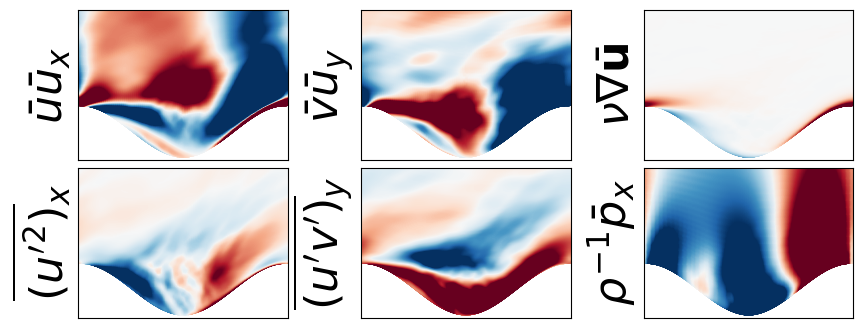

In [10]:
# Plot all six terms in the RANS equation
fig = plt.figure(figsize=(10, 4))
# labels = [r'$\bar{u} \bar{u}_x$', r'$\bar{v}\bar{u}_y$', r'$\rho^{-1} \bar{p}_x$',
#           r'$\nu \nabla^2 \bar{u}$', r'$\overline{(u^\prime v^\prime)}_y$', r'$\overline{({u^\prime} ^2)}_x$']
clim = 2e-1
fontsize=32

cmap = plt.colormaps['RdBu'].copy()
cmap.set_bad('white')

plt.subplot(231)
field = features[:,0]
plt.scatter(masked_x_coords_DNS_grid[mask], masked_y_coords_DNS_grid[mask], 2, field[mask], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[0], fontsize=fontsize)

plt.subplot(232)
field = features[:,1]
plt.scatter(masked_x_coords_DNS_grid[mask], masked_y_coords_DNS_grid[mask], 2, field[mask], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[1], fontsize=fontsize)

plt.subplot(233)
field = features[:,2]
plt.scatter(masked_x_coords_DNS_grid[mask], masked_y_coords_DNS_grid[mask], 2, field[mask], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[2], fontsize=fontsize)

plt.subplot(236)
field = features[:,3]
plt.scatter(masked_x_coords_DNS_grid[mask], masked_y_coords_DNS_grid[mask], 2, field[mask], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[3], fontsize=fontsize)

plt.subplot(234)
field = features[:,4]
plt.scatter(masked_x_coords_DNS_grid[mask], masked_y_coords_DNS_grid[mask], 2, field[mask], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[4], fontsize=fontsize)

plt.subplot(235)
field = features[:,5]
plt.scatter(masked_x_coords_DNS_grid[mask], masked_y_coords_DNS_grid[mask], 2, field[mask], vmin=-clim, vmax=clim, cmap=cmap)
plt.gca().set_xticks([])
plt.gca().set_yticks([])
plt.xlim(1.0,3.0)
plt.ylim(0.0,0.58)
plt.ylabel(labels[5], fontsize=fontsize)

fig.patch.set_alpha(0)

plt.subplots_adjust(left=None, bottom=None, right=None, top=None, wspace=0.35, hspace=0.05)

plt.savefig('DNSWavyWall_WeakTerms_PressLast.png',dpi=480)#,bbox_inches='tight'

plt.show()

In [13]:
# make a mask for the data
TF_Centers = np.vstack([x_centers.flatten(),y_centers.flatten()]).T

'''
Make the mask to runcate erroneous conolved data
'''
mask = numpy.ones(TF_Centers.shape[0])

# new mask, probably faster?
t0 = time.time()

cutoff = x_range.size # I can change the size of the domain of interest for quick debugging

x_TF_0 = TF_Centers[:cutoff,0] - support_bound_x
x_TF_F = TF_Centers[:cutoff,0] + support_bound_x

ranges = []
idx = 0
for start,end in zip(x_TF_0, x_TF_F):
    ranges.append(np.linspace(start,end,int((2*support_bound_x)/grid_spacing + 1)))
    idx+=1

ranges = np.array(ranges)

max_wall_boundary = np.max(wavyWallCurve(ranges), axis=1)

full_grid_of_max_wall_boundary_for_a_given_TF_center = np.tile(max_wall_boundary, (y_range.size,1))

mask = np.where((TF_Centers[:,1]-support_bound_y) <= full_grid_of_max_wall_boundary_for_a_given_TF_center.flatten(), 0, mask)

mask = np.reshape(mask, UU_x_weak.shape)

# print(mask[0])

# print(time.time()-t0)

mask = numpy.array(mask)[0:int(yF/grid_spacing + 1),:]
erroneous_support_buffer_x = int(support_bound_x/dx) + 1
erroneous_support_buffer_y = int(support_bound_y/dy) + 1

# Truncate errors on the bounds
mask[:,0:erroneous_support_buffer_x] = 0
mask[:,(-erroneous_support_buffer_x-1):] = 0
mask[(-erroneous_support_buffer_y-1):,:] = 0

mask = np.array(mask.astype(bool))


NameError: name 'UU_x_weak' is not defined

In [ ]:
plt.figure(figsize = (15,4))
plt.scatter(masked_x_coords_DNS_grid,masked_y_coords_DNS_grid,2,UU_x_weak[mask], vmin=-0.1, vmax = 0.1)
plt.colorbar()
plt.savefig(save_dir + 'terms/' + f'UU_x_weak', dpi=480)
plt.close()

plt.figure(figsize = (15,4))
plt.scatter(masked_x_coords_DNS_grid,masked_y_coords_DNS_grid,2,VU_y_weak[mask], vmin=-0.1, vmax = 0.1)
plt.colorbar()
plt.savefig(save_dir + 'terms/' + f'VU_y_weak',dpi=480)
plt.close()
